In [49]:
import pymcel as pc
from scipy.integrate import odeint
import random
import math
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
G = 1

In [ ]:
m_central = 50
num_stars = 50
position_radius = 10.0

sistema = [
    dict(m=m_central, r=[0, 0, 0], v=[0, 0, 0])
 ]

for _ in range(num_stars):
    # Uniform sample in disk area for positions
    rho = position_radius * math.sqrt(random.random())
    theta = 2 * math.pi * random.random()
    x = rho * math.cos(theta)
    y = rho * math.sin(theta)

    # Speed varies slightly around local escape velocity
    r = max(rho, 1e-6)
    v_escape = math.sqrt(2 * G * m_central / r)
    v_mag = v_escape * random.uniform(0.95, 1.05)

    # Random velocity direction in the plane
    vtheta = 2 * math.pi * random.random()
    vx = v_mag * math.cos(vtheta)
    vy = v_mag * math.sin(vtheta)

    sistema.append(dict(m=0.1, r=[x, y, 0], v=[vx, vy, 0]))

In [51]:
print(sistema)

[{'m': 50, 'r': [0, 0, 0], 'v': [0, 0, 0]}, {'m': 1, 'r': [1.8374758035016836, -5.500839257967874, 0], 'v': [0.0890342452436732, 0.1733715481800211, 0]}, {'m': 1, 'r': [-2.5316710347513838, 2.0357344859242357, 0], 'v': [-0.24517960361918983, -0.339677004641536, 0]}, {'m': 1, 'r': [3.2797005241140216, -2.7921122168975283, 0], 'v': [0.2050508123803164, -0.16809054971532042, 0]}, {'m': 1, 'r': [8.045027664650531, 2.780295502374459, 0], 'v': [0.32161221043332405, -0.3415568150229384, 0]}, {'m': 1, 'r': [-1.7329291423499649, 8.282478683247112, 0], 'v': [-0.4117310118474551, -0.03493513447675782, 0]}, {'m': 1, 'r': [-1.3870061171777586, 1.665339243340463, 0], 'v': [0.15944963473052443, -0.36348465469401015, 0]}, {'m': 1, 'r': [9.21753680579661, 0.5108528086981428, 0], 'v': [0.1373552569681921, -0.136882512203304, 0]}, {'m': 1, 'r': [7.67895701811734, 5.115138016404367, 0], 'v': [-0.03880253622341715, 0.45936559186361053, 0]}, {'m': 1, 'r': [4.244411499313776, -8.079804045430162, 0], 'v': [-0

In [52]:
ts = np.linspace(0, 100, 1000)
rs, vs, rps, vps, constantes = pc.ncuerpos_solucion(sistema, ts)

In [53]:
rps[0,0,0]

np.float64(-0.19571889518616672)

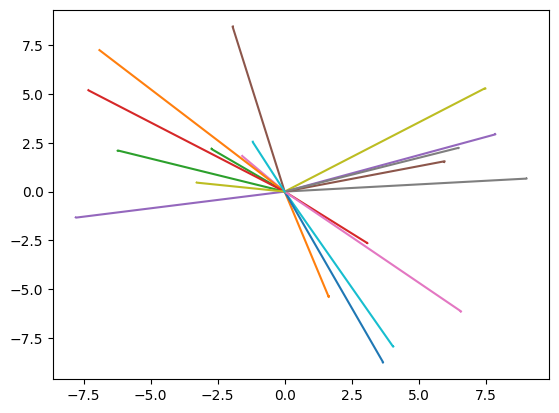

In [54]:
plt.plot(rps[0, :, 0], rps[0, :, 1],"-")
for i in range(1, 20):
    plt.plot(rps[i, :, 0], rps[i, :, 1],"-")